<a href="https://colab.research.google.com/github/Viktoriia-code26/goit_DS_ML_Hw-09/blob/main/ML_Hw_09_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST — сравнение моделей

Оставлены только самые показательные варианты: базовая Dense-модель, лучшая полносвязная модель и CNN.


In [1]:

from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_flat = x_train.reshape(-1, 784).astype('float32') / 255
x_test_flat = x_test.reshape(-1, 784).astype('float32') / 255
print(x_train.shape, x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


## 1. Базовая Dense-модель


In [3]:

model_1 = Sequential([
    Dense(300, activation='relu', input_shape=(784,)),
    Dense(300, activation='relu'),
    Dense(10, activation='softmax'),
])

model_1.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_1 = model_1.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
)

test_loss_1, test_acc_1 = model_1.evaluate(x_test_flat, y_test)
print(f"Test accuracy: {test_acc_1 * 100:.2f}%")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7395 - loss: 0.7264 - val_accuracy: 0.7872 - val_loss: 0.6274
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8273 - loss: 0.4728 - val_accuracy: 0.8163 - val_loss: 0.5016
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8489 - loss: 0.4110 - val_accuracy: 0.8445 - val_loss: 0.4356
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8605 - loss: 0.3718 - val_accuracy: 0.8635 - val_loss: 0.3806
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8691 - loss: 0.3480 - val_accuracy: 0.8433 - val_loss: 0.4282
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8786 - loss: 0.3256 - val_accuracy: 0.8682 - val_loss: 0.3570
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8842 - loss: 0.3093 - val_accuracy: 0.8670 - val_loss: 0.3611
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8876 - loss: 0.2968 - val_accu

In [4]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,622 (2.51 MB)

 Trainable params: 328,810 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 328,812 (1.25 MB)

In [10]:
print(f"""Вывод:
Базовая модель дает {test_acc_1 * 100:.2f} accuracy
Это хороший ориентир, но видно, что архитектуру можно улучшить.""")

Вывод:
Базовая модель дает 86.24 accuracy
Это хороший ориентир, но видно, что архитектуру можно улучшить.


## 2. Лучшая Dense-модель (GELU)


In [5]:

model_10 = Sequential([
    Input(shape=(784,)),

    Dense(512, activation='gelu'),
    Dropout(0.1),

    Dense(256, activation='gelu'),
    Dropout(0.1),

    Dense(128, activation='gelu'),

    Dense(10, activation='softmax')
])

model_10.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

history_10 = model_10.fit(
    x_train_flat,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr]
)

test_loss_10, test_acc_10 = model_10.evaluate(x_test_flat, y_test)


print(f"Test accuracy: {test_acc_10:.4f}")
print(f"Test accuracy: {test_acc_10 * 100:.2f}%")

Epoch 1/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8173 - loss: 0.5095 - val_accuracy: 0.8490 - val_loss: 0.3965 - learning_rate: 3.0000e-04
Epoch 2/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8637 - loss: 0.3683 - val_accuracy: 0.8715 - val_loss: 0.3507 - learning_rate: 3.0000e-04
Epoch 3/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8781 - loss: 0.3253 - val_accuracy: 0.8788 - val_loss: 0.3368 - learning_rate: 3.0000e-04
Epoch 4/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8874 - loss: 0.2988 - val_accuracy: 0.8692 - val_loss: 0.3475 - learning_rate: 3.0000e-04
Epoch 5/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8967 - loss: 0.2766 - val_accuracy: 0.8918 - val_loss: 0.2941 - learning_rate: 3.0000e-04
Epoch 6/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9030 - loss: 0.2586 - val_accuracy: 0.8682 - val_loss: 0.3544 - learning_rate: 3.0000e-04
Epoch 7/60
1688/1688 ━━━━━━━━━━━━━━━━━━━━

In [6]:
model_10.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,304 (6.49 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,134,870 (4.33 MB)

In [14]:
print(f"""Вывод:
Среди полносвязных вариантов лучший результат — {test_acc_10 * 100:.2f}.
GELU + Dropout + уменьшение learning rate дали прирост примерно {(test_acc_10 - test_acc_1) * 100:.2f}п.п. относительно baseline.""")

Вывод:
Среди полносвязных вариантов лучший результат — 90.48.
GELU + Dropout + уменьшение learning rate дали прирост примерно 4.24 п.п. относительно baseline.


## 3. CNN — лучший результат


In [15]:
import keras

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Подготовка изображений для CNN
x_train_cnn = x_train.astype('float32')[..., None] / 255
x_test_cnn = x_test.astype('float32')[..., None] / 255

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train_cnn,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping]
)

test_loss_cnn, test_acc_cnn = model.evaluate(x_test_cnn, y_test)
print(f"Test accuracy: {test_acc_cnn * 100:.2f}%")


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 63s 73ms/step - accuracy: 0.8216 - loss: 0.4984 - val_accuracy: 0.8787 - val_loss: 0.3264
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 73ms/step - accuracy: 0.8835 - loss: 0.3226 - val_accuracy: 0.8867 - val_loss: 0.3042
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.9002 - loss: 0.2743 - val_accuracy: 0.9083 - val_loss: 0.2483
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.9107 - loss: 0.2437 - val_accuracy: 0.9143 - val_loss: 0.2372
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.9195 - loss: 0.2217 - val_accuracy: 0.9152 - val_loss: 0.2370
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - accuracy: 0.9261 - loss: 0.2012 - val_accuracy: 0.9167 - val_loss: 0.2260
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 60s 71ms/step - accuracy: 0.9329 - loss: 0.1836 - val_accuracy: 0.9185 - val_loss: 0.2253
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 59s 70ms/step - accuracy: 0.9373 - loss: 0.1690 - 

In [16]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [18]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


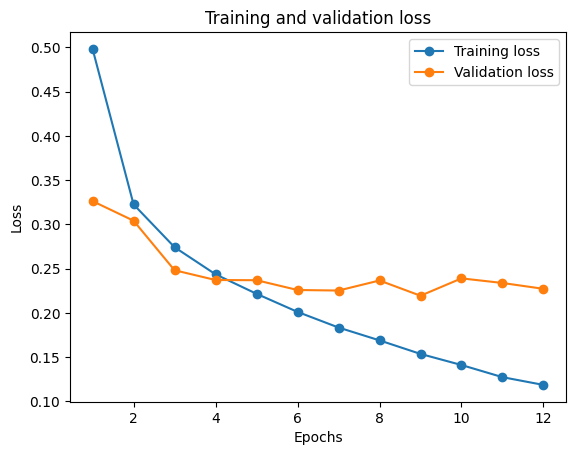

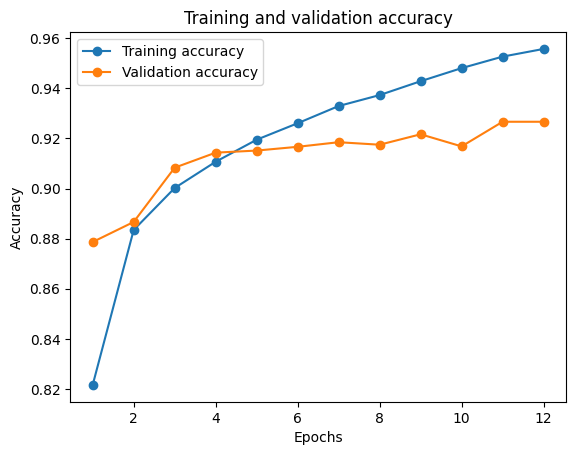

In [19]:
# Візуалізуємо

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(history_dict['accuracy']) + 1)

plt.plot(epochs, loss_values, 'o-', label='Training loss')
plt.plot(epochs, val_loss_values, 'o-', label='Validation loss')

plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, history_dict['accuracy'], 'o-', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'o-', label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [20]:
print("Итоговые результаты:")
print(f"Baseline Dense: {test_acc_1 * 100:.2f}%")
print(f"Dense GELU:     {test_acc_10 * 100:.2f}%")
print(f"CNN:            {test_acc_cnn * 100:.2f}%")

best = max(
    ("Baseline Dense", test_acc_1),
    ("Dense GELU", test_acc_10),
    ("CNN", test_acc_cnn),
    key=lambda x: x[1]
)

print(f"\nЛучший результат: {best[0]} — {best[1] * 100:.2f}%")

Итоговые результаты:
Baseline Dense: 86.24%
Dense GELU:     90.48%
CNN:            92.16%

Лучший результат: CNN — 92.16%


In [23]:
print(f"""Вывод

В работе сравнивались разные нейросетевые архитектуры для Fashion MNIST.
Базовая Dense-модель показала {test_acc_1 * 100:.2f}%,
улучшенная Dense-модель с GELU — {test_acc_10 * 100:.2f}%,
а лучший результат получила сверточная сеть CNN — {test_acc_cnn * 100:.2f}%.

Усложнение обычной Dense-сети дает небольшой прирост, но переход к CNN работает лучше,
потому что сверточные слои учитывают пространственную структуру изображения.
Поэтому для задачи классификации изображений CNN оказалась наиболее подходящей моделью.
""")

Вывод

В работе сравнивались разные нейросетевые архитектуры для Fashion MNIST. 
Базовая Dense-модель показала 86.24%, 
улучшенная Dense-модель с GELU — 90.48%, 
а лучший результат получила сверточная сеть CNN — 92.16%.

Усложнение обычной Dense-сети дает небольшой прирост, но переход к CNN работает лучше, 
потому что сверточные слои учитывают пространственную структуру изображения. 
Поэтому для задачи классификации изображений CNN оказалась наиболее подходящей моделью.

